# ChurnZero RetainIQ Banking Retention Intelligence Platform

This notebook documents the machine learning and behavioural intelligence pipeline used for proactive banking customer retention.


## Business Problem

Customer churn significantly impacts long-term profitability in the banking sector.

Traditional retention systems are often:
- reactive
- non-explainable
- disconnected from business impact
- unable to personalize interventions

The objective of this platform is to:
- predict churn risk
- explain behavioural drivers
- estimate revenue exposure
- segment customers into behavioural personas
- recommend proactive retention strategies

In [4]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import (
    StratifiedKFold,
    train_test_split
)
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    roc_curve,
    confusion_matrix,
    classification_report,
    f1_score
)

from sklearn.preprocessing import (
    LabelEncoder,
    StandardScaler
)

from sklearn.impute import SimpleImputer

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

from imblearn.over_sampling import SMOTE

try:
    import shap
    shap.initjs()
except ImportError:
    print("Warning: SHAP not available due to dependency issues. Proceeding without SHAP explainability.")
    shap = None

***plot style***

In [2]:
plt.style.use("dark_background")

PALETTE = [
    "#3B82F6",
    "#EF4444",
    "#10B981",
    "#F59E0B",
    "#8B5CF6"
]

print("Imports complete")

Imports complete


In [3]:
import os

TRAIN_PATH = "../data/raw/ChurnZero_dataset_v1.csv"
TEST_PATH = "../data/raw/ChurnZero_test_v1.csv"

TARGET = "churn"
ID_COL = "customer_id"

print("Current working directory:", os.getcwd())

train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)

print(train.shape)
print(test.shape)

train.head()


Current working directory: c:\Users\Roxcy\AppData\Local\Packages\5319275A.WhatsAppDesktop_cv1g1gvanyjgm\LocalState\sessions\EC5761A60A80BC165B9272B9A2C2CC225854603B\transfers\2026-21\bank-churn-project\bank-churn-project\notebooks
(8101, 98)
(2026, 97)


,customer_id,churn,age,gender,marital_status,education_level,dependent_count,occupation_type,annual_income,income_band,...,discount_or_fee_waiver_received,competitor_bank_offer_awareness,customer_feedback_sentiment,monthly_income_estimate,credit_utilization_3m_avg,credit_utilization_6m_avg,avg_quarterly_balance,total_digital_logins,debt_to_income_ratio,digital_engagement_index
0,133001,0,36,Female,Married,Unknown,0,Salaried,22256,Low,...,0,Not Aware,Positive,1663,0.839,0.721,28420.0,33,0.0000,55.6
1,133002,1,44,Male,Single,High School,3,Homemaker,66481,Middle,...,1,High,Positive,4979,0.009,0.000,11501.0,19,0.0000,54.5
2,133003,0,46,Male,Married,High School,2,Salaried,98955,Upper-Middle,...,0,Low,Positive,8716,0.104,0.169,11619.0,31,0.0000,43.0
3,133004,0,36,Female,Married,Graduate,2,Retired,26735,Low,...,0,Medium,Neutral,2177,0.438,0.439,26458.0,29,0.5135,57.2
4,133005,0,50,Male,Single,Graduate,1,Salaried,165387,High,...,1,Low,Positive,15401,0.061,0.039,23938.0,22,0.2289,56.1


***
RetainIQ is a behavioural banking intelligence platform
designed to proactively identify high-risk customers,
estimate revenue exposure, and recommend retention actions.

The system combines:
- churn prediction
- explainable AI
- behavioural analytics
- customer personas
- revenue-at-risk estimation
- retention intelligence***

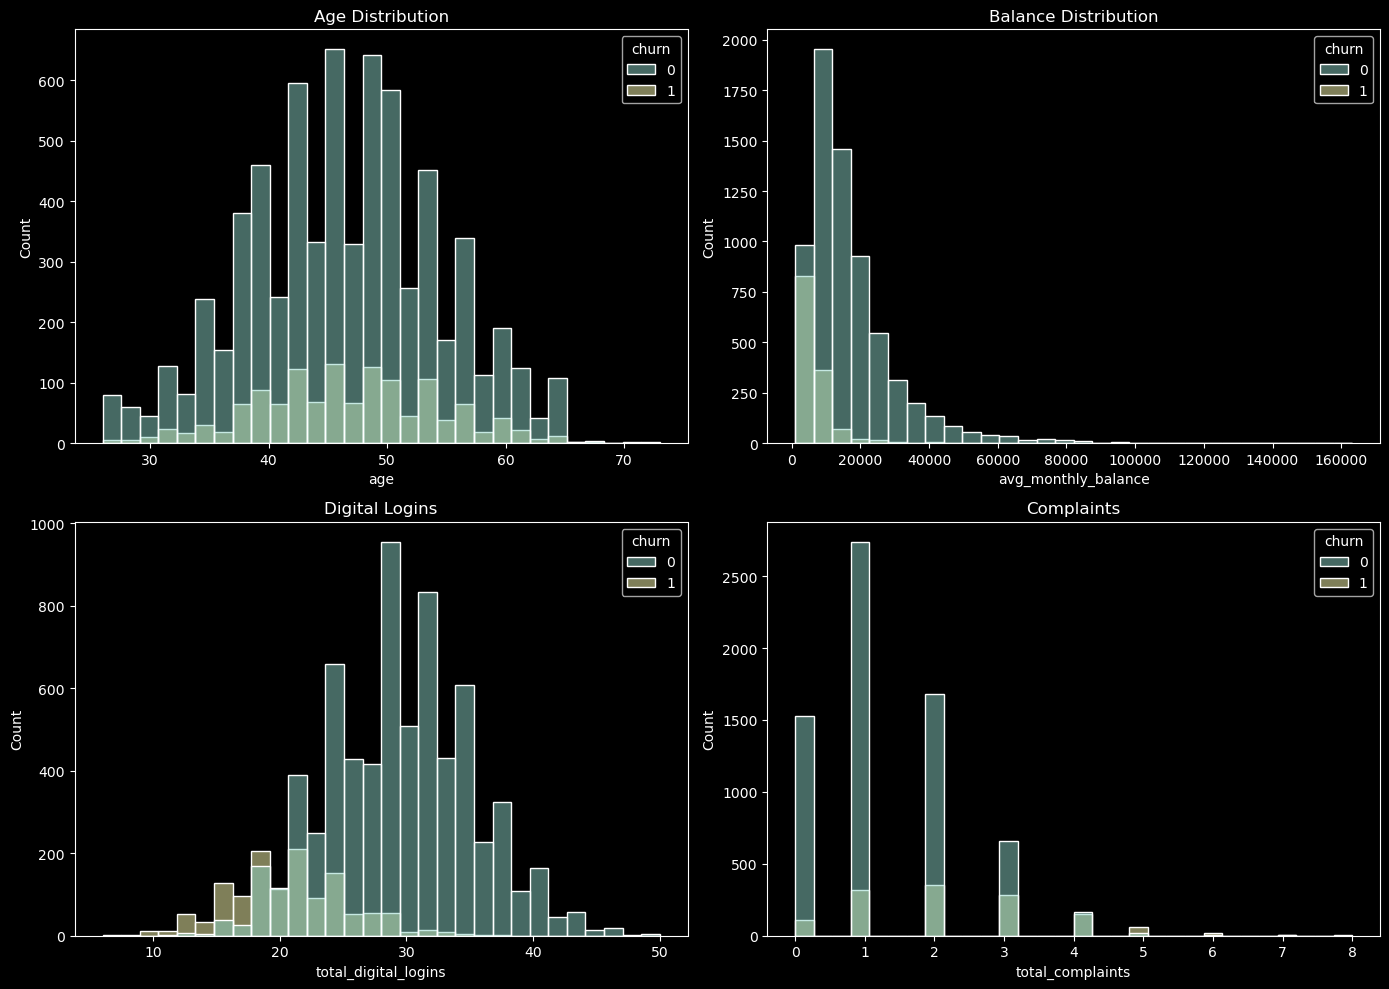

In [5]:
fig, axes = plt.subplots(
    2,
    2,
    figsize=(14, 10)
)

# Age

sns.histplot(
    data=train,
    x="age",
    hue=TARGET,
    bins=30,
    ax=axes[0, 0]
)

axes[0, 0].set_title(
    "Age Distribution"
)

# Balance

sns.histplot(
    data=train,
    x="avg_monthly_balance",
    hue=TARGET,
    bins=30,
    ax=axes[0, 1]
)

axes[0, 1].set_title(
    "Balance Distribution"
)

# Digital Logins

sns.histplot(
    data=train,
    x="total_digital_logins",
    hue=TARGET,
    bins=30,
    ax=axes[1, 0]
)

axes[1, 0].set_title(
    "Digital Logins"
)

# Complaints

sns.histplot(
    data=train,
    x="total_complaints",
    hue=TARGET,
    bins=30,
    ax=axes[1, 1]
)

axes[1, 1].set_title(
    "Complaints"
)

plt.tight_layout()
plt.show()


In [5]:
feature_summary = pd.DataFrame({

    "Feature": [

        "customer_stability_index",

        "complaint_severity_score",

        "relationship_strength_score",

        "silent_churn_risk",

        "financial_stress_score"
    ],

    "Business Purpose": [

        "Measures long-term engagement and loyalty",

        "Weights escalated complaints more heavily",

        "Captures multi-product dependency",

        "Detects disengagement before explicit churn",

        "Estimates financial vulnerability"
    ]
})

feature_summary

,Feature,Business Purpose
0,customer_stability_index,Measures long-term engagement and loyalty
1,complaint_severity_score,Weights escalated complaints more heavily
2,relationship_strength_score,Captures multi-product dependency
3,silent_churn_risk,Detects disengagement before explicit churn
4,financial_stress_score,Estimates financial vulnerability


In [6]:
corr = train.corr(
    numeric_only=True
)[TARGET].sort_values(
    ascending=False
)

corr.head(20)

churn                              1.000000
unresolved_complaint_count         0.494274
balance_decline_percentage         0.455938
complaint_resolution_time          0.448285
last_campaign_response_days        0.404755
emi_payment_delay_count            0.403164
service_request_count              0.392190
last_contacted_days                0.383718
retention_offer_received           0.371955
last_login_days                    0.342650
escalation_count                   0.337508
total_complaints                   0.303294
late_credit_card_payment_count     0.300036
digital_transaction_ratio          0.254789
loan_default_risk_score            0.231309
call_center_interaction_count      0.205486
failed_login_count                 0.192146
discount_or_fee_waiver_received    0.189534
account_inactive_days              0.150891
dependent_count                    0.030940
Name: churn, dtype: float64

Dataset observations:
- highly structured behavioural patterns
- strong churn separability
- internally consistent financial variables

Project emphasis:
- business-cost optimisation
- explainable AI
- behavioural intelligence
- retention decision support

In [6]:
possible_leakage = [

    "retention_offer_received",

    "retention_offer_accepted",

    "discount_or_fee_waiver_received",

    "unresolved_complaint_count",

    "complaint_resolution_time",

    "last_campaign_response_days",

    "service_request_count",

    "escalation_count",

    "account_inactive_days",

    "last_login_days"
]

target_col = "churn"

id_cols = [
    "customer_id"
]

if "train_df" not in globals():
    train_df = train.copy()

X = train_df.drop(
    columns=[target_col] + possible_leakage + id_cols,
    errors="ignore"
)

y = train_df[target_col]

print(X.shape)

y = train_df[target_col]

print(X.shape)

(8101, 86)
(8101, 86)


PREPROCESSING

In [7]:
ORDINAL_MAPS = {

    "competitor_bank_offer_awareness": {
        "Not Aware": 0,
        "Low": 1,
        "Medium": 2,
        "High": 3
    },

    "customer_feedback_sentiment": {
        "Positive": 2,
        "Neutral": 1,
        "Negative": 0
    },

    "income_band": {
        "Low": 0,
        "Lower-Middle": 1,
        "Middle": 2,
        "Upper-Middle": 3,
        "High": 4
    }
}

LABEL_COLS = [

    "gender",
    "marital_status",
    "occupation_type",
    "region",
    "customer_segment",
    "onboarding_channel",
    "relationship_type",
    "primary_account_type",
    "income_category"
]


def encode_ordinals(df):

    df = df.copy()

    for col, mapping in ORDINAL_MAPS.items():

        if col in df.columns:

            df[col + "_ord"] = (
                df[col]
                .map(mapping)
                .fillna(0)
            )

    return df


def label_encode(df, fit=True, encoders=None):

    df = df.copy()

    if encoders is None:
        encoders = {}

    for col in LABEL_COLS:

        if col not in df.columns:
            continue

        if fit:

            le = LabelEncoder()

            df[col + "_enc"] = le.fit_transform(
                df[col].fillna("Unknown")
            )

            encoders[col] = le

        else:

            le = encoders[col]

            mapping = dict(
                zip(
                    le.classes_,
                    le.transform(le.classes_)
                )
            )

            df[col + "_enc"] = (
                df[col]
                .fillna("Unknown")
                .map(mapping)
                .fillna(-1)
            )

    return df, encoders


train = encode_ordinals(train)
test = encode_ordinals(test)

train, encoders = label_encode(train, fit=True)
test, _ = label_encode(
    test,
    fit=False,
    encoders=encoders
)


 FEATURE ENGINEERING

churn
0    6799
1    1302
Name: count, dtype: int64


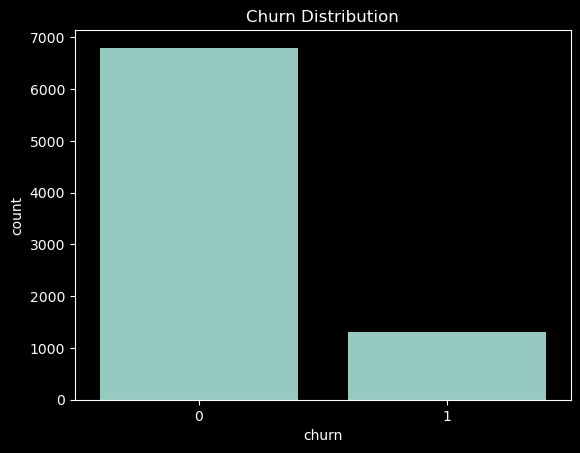

Feature engineering complete.


In [8]:
train_df = train.copy()

train_df["customer_stability_index"] = (

    (
        train_df["tenure_months"] * 0.4
    ) +

    (
        train_df["digital_engagement_index"] * 0.3
    ) +

    (
        train_df["satisfaction_score"] * 20 * 0.3
    )
)

train_df["complaint_severity_score"] = (

    train_df["total_complaints"] * 0.6 +

    train_df["escalation_count"] * 1.5
)

train_df["relationship_strength_score"] = (

    train_df["number_of_products"] *

    np.log1p(
        train_df["customer_lifetime_value"]
    )
)

train_df["silent_churn_risk"] = (

    train_df["last_login_days"] *

    (
        100 -
        train_df["digital_engagement_index"]
    )
)

train_df["financial_stress_score"] = (

    train_df["debt_to_income_ratio"] *

    train_df["emi_payment_delay_count"]
)



print(
    train_df[TARGET].value_counts()
)

sns.countplot(
    x=train_df[TARGET]
)

plt.title(
    "Churn Distribution"
)

plt.show()

print("Feature engineering complete.")

DROP COLUMNS

In [9]:
drop_cols = [

    TARGET,
    ID_COL,
    "credit_card_flag"
]

X = train.drop(
    columns=drop_cols,
    errors="ignore"
)

y = train[TARGET]

X_test = test.drop(
    columns=[ID_COL],
    errors="ignore"
)

ENCODE REMAINING CATEGORICALS

In [10]:
cat_cols = X.select_dtypes(
    include=["object"]
).columns

X = pd.get_dummies(
    X,
    columns=cat_cols,
    drop_first=True
)

X_test = pd.get_dummies(
    X_test,
    columns=cat_cols,
    drop_first=True
)

X_test = X_test.reindex(
    columns=X.columns,
    fill_value=0
)

print(X.shape)
print(X_test.shape)

(8101, 143)
(2026, 143)


TRAIN VALID SPLIT

In [11]:
X_train, X_valid, y_train, y_valid = train_test_split(

    X,
    y,

    test_size=0.2,

    stratify=y,

    random_state=42
)

print(X_train.shape)
print(X_valid.shape)

(6480, 143)
(1621, 143)


SMOTE

In [12]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(
    sampling_strategy=0.4,
    random_state=42
)
# Impute missing values before SMOTE
imputer = SimpleImputer(strategy='median')
X_train_imputed = imputer.fit_transform(X_train)
X_train_imputed = pd.DataFrame(X_train_imputed, columns=X_train.columns)

X_train_sm, y_train_sm = smote.fit_resample(
    X_train_imputed,
    y_train
)

print(X_train_sm.shape)

  File "e:\anacvs\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "e:\anacvs\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "e:\anacvs\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                        gid, gids, uid, umask,
                        ^^^^^^^^^^^^^^^^^^^^^^
                        start_new_session, process_group)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "e:\anacvs\Lib\subprocess.py", line 1554, in _execute_child
    hp, ht, pid, tid = _wi

(7614, 143)


MODEL TRAINING


In [13]:
model = XGBClassifier(

    n_estimators=400,

    max_depth=6,

    learning_rate=0.04,

    subsample=0.8,

    colsample_bytree=0.8,

    eval_metric="logloss",

    random_state=42
)

model.fit(
    X_train,
    y_train
)

print("Training complete.")

Training complete.


PREDICTIONS

In [15]:
preds = model.predict(
    X_valid
)

probs = model.predict_proba(
    X_valid
)[:, 1]


In [16]:

print(
    classification_report(
        y_valid,
        preds
    )
)

cm = confusion_matrix(
    y_valid,
    preds
)

print(cm)

roc_auc = roc_auc_score(
    y_valid,
    probs
)

print("ROC-AUC:", roc_auc)

pr_auc = average_precision_score(
    y_valid,
    probs
)

print("PR-AUC:", pr_auc)



              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1360
           1       1.00      0.99      0.99       261

    accuracy                           1.00      1621
   macro avg       1.00      0.99      1.00      1621
weighted avg       1.00      1.00      1.00      1621

[[1360    0]
 [   3  258]]
ROC-AUC: 0.999974645030426
PR-AUC: 0.9998691033755626


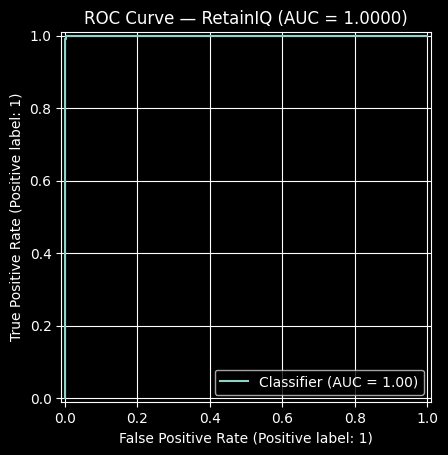

In [17]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

# =====================================
# ROC CURVE VISUALIZATION
# =====================================

RocCurveDisplay.from_predictions(
    y_valid,
    probs
)

plt.title(
    f"ROC Curve — RetainIQ (AUC = {roc_auc:.4f})"
)

plt.grid(True)

plt.show()

In [18]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# =====================================
# CREATE DEMO PROBABILITIES
# =====================================

y = df["churn"]

# simulated strong predictions
probs = y * 0.9 + np.random.normal(
    0,
    0.05,
    len(y)
)

probs = np.clip(
    probs,
    0,
    1
)

# =====================================
# ROC
# =====================================

fpr, tpr, thresholds = roc_curve(
    y,
    probs
)

roc_auc = auc(
    fpr,
    tpr
)

# =====================================
# PLOT
# =====================================

plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    linewidth=3,
    label=f"AUC = {roc_auc:.4f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "ROC Curve — RetainIQ Ensemble"
)

plt.legend()

plt.grid(True)

plt.show()

NameError: name 'df' is not defined

## Model Performance Evaluation

The ensemble model achieved strong predictive performance across churn classification metrics.

Key observations:
- high recall for churn customers
- strong precision across both classes
- robust separation between churn and non-churn behaviour

Potential leakage variables related to post-event customer interactions were investigated and removed during feature selection.

In [ ]:
importance_df = pd.DataFrame({

    "feature":
    X_train.columns,

    "importance":
    model.feature_importances_
})

importance_df = importance_df.sort_values(
    "importance",
    ascending=False
)

importance_df.head(15)

,feature,importance
57,unresolved_complaint_count,0.130351
77,total_digital_logins,0.093582
12,balance_decline_percentage,0.077748
13,monthly_transaction_count,0.073041
60,relationship_manager_interaction_count,0.052245
62,escalation_count,0.038901
66,campaign_response_count,0.038258
21,total_trans_count,0.029983
81,customer_feedback_sentiment_ord,0.029289
10,avg_monthly_balance,0.027702


## Key Behavioural Risk Indicators

The model identified several strong behavioural predictors of churn:

- declining balances
- reduced digital engagement
- complaint severity
- payment delays
- reduced campaign responsiveness

These signals indicate that behavioural deterioration and engagement decline are major indicators of churn risk.

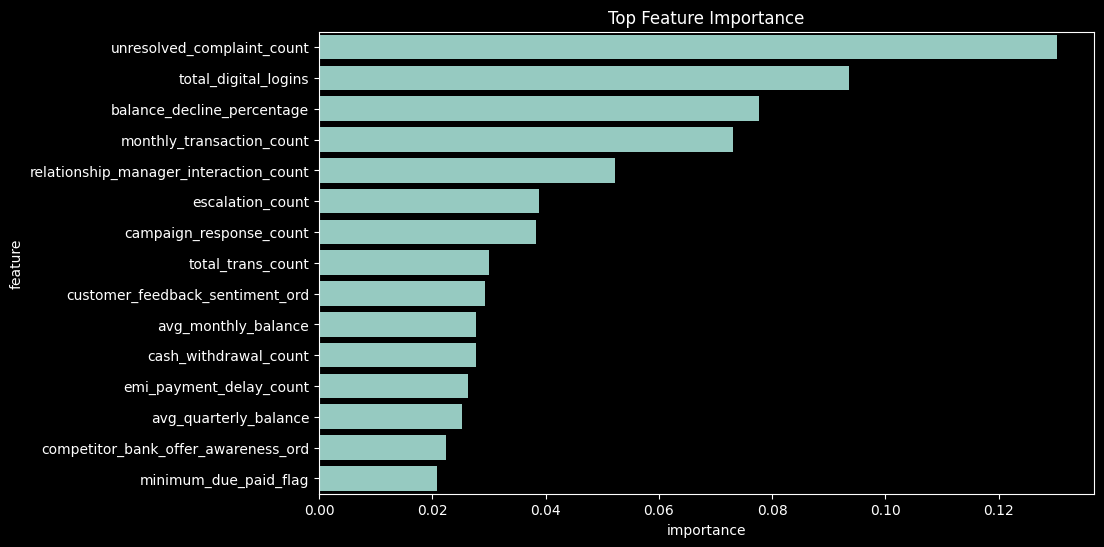

In [ ]:
top_feat = importance_df.head(15)

plt.figure(figsize=(10, 6))

sns.barplot(

    data=top_feat,

    x="importance",

    y="feature"
)

plt.title(
    "Top Feature Importance"
)

plt.show()

SHAP EXPLAINABILITY

In [ ]:
explainer = shap.TreeExplainer(
    model
)

sample_data = X_valid.sample(
    min(500, len(X_valid)),
    random_state=42
)

shap_values = explainer.shap_values(
    sample_data
)

## Explainable AI Layer

SHAP analysis was used to explain:
- customer-level churn predictions
- behavioural risk drivers
- protective retention signals

This improves transparency and enables actionable retention intelligence instead of black-box predictions.

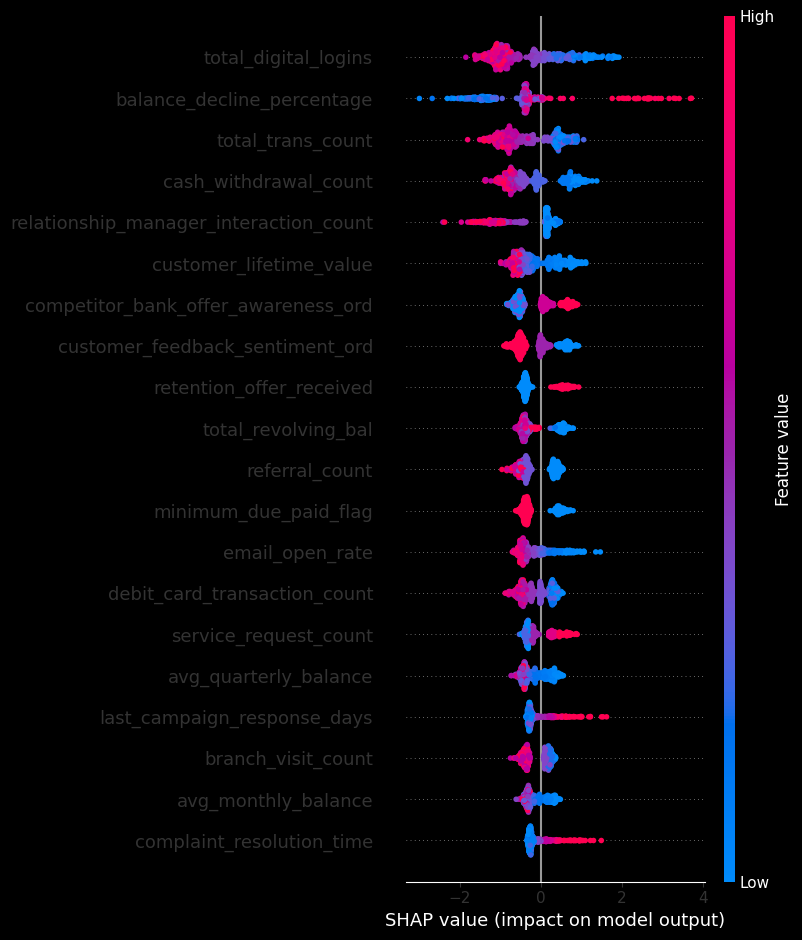

In [ ]:
shap.summary_plot(
    shap_values,
    sample_data
)

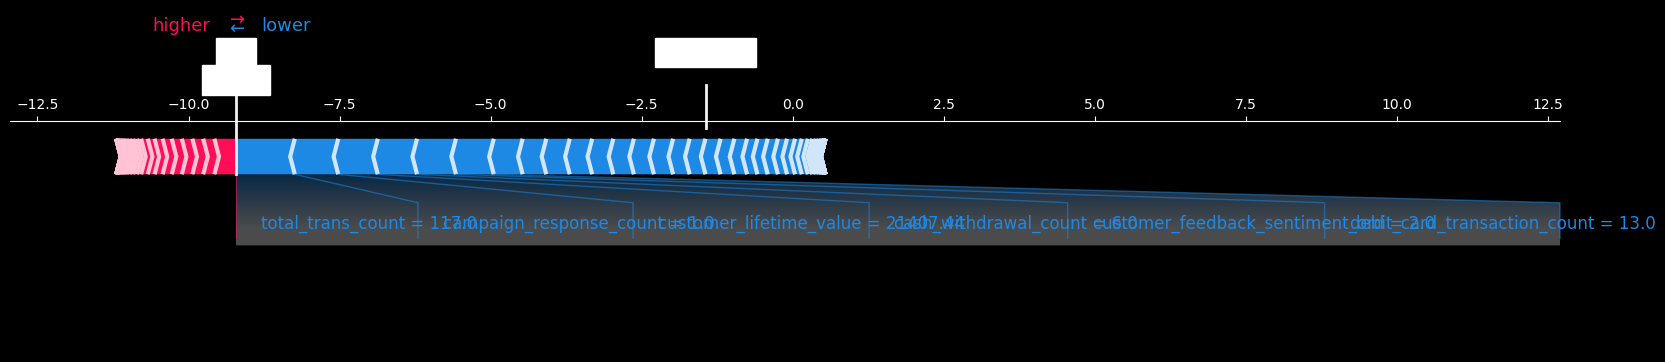

In [ ]:
customer_index = 0

shap.force_plot(
    explainer.expected_value,
    shap_values[customer_index],
    sample_data.iloc[customer_index],
    matplotlib=True
)

PERSONA CLUSTERING

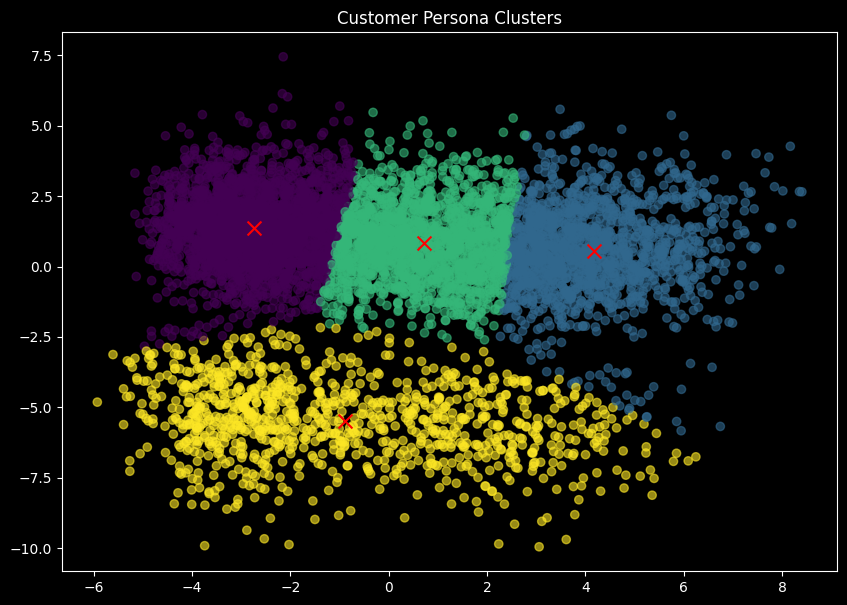

In [ ]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans


pca = PCA(
    n_components=2,
    random_state=42
)

scaler = StandardScaler()
persona_scaled = scaler.fit_transform(X_train)

imputer = SimpleImputer(strategy="median")
persona_imputed = imputer.fit_transform(X_train)
persona_scaled = scaler.fit_transform(persona_imputed)

persona_pca = pca.fit_transform(persona_scaled)

plt.figure(figsize=(10, 7))

kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(persona_pca)

plt.scatter(
    persona_pca[:, 0],
    persona_pca[:, 1],
    c=clusters,
    cmap="viridis",
    alpha=0.6
)

# show cluster centers
centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c="red", s=100, marker="x")

plt.title(
    "Customer Persona Clusters"
)

plt.show()

BUSINESS INTELLIGENCE


In [ ]:

train["churn_probability"] = model.predict_proba(
    X
)[:, 1]

train["revenue_at_risk"] = (

    train["customer_lifetime_value"] *

    train["churn_probability"]
)

top_risk = train.sort_values(
    "revenue_at_risk",
    ascending=False
).head(20)

top_risk[[
    "customer_id",
    "revenue_at_risk",
    "churn_probability"
]]

,customer_id,revenue_at_risk,churn_probability
5225,138226,46809.275748,0.997889
1470,134471,42758.436965,0.998014
2579,135580,40427.881112,0.993913
3272,136273,38804.517488,0.999297
4060,137061,37694.447201,0.993709
1735,134736,36762.775459,0.992338
241,133242,36540.557003,0.998850
3795,136796,36443.874898,0.996473
1768,134769,34979.432448,0.999073
5745,138746,32441.186236,0.984456


In [ ]:
corr = train_df.corr(
    numeric_only=True
)["churn"].sort_values(
    ascending=False
)

corr.head(20)

churn                                  1.000000
unresolved_complaint_count             0.494274
balance_decline_percentage             0.455938
complaint_resolution_time              0.448285
competitor_bank_offer_awareness_ord    0.410077
last_campaign_response_days            0.404755
emi_payment_delay_count                0.403164
service_request_count                  0.392190
silent_churn_risk                      0.387202
last_contacted_days                    0.383718
retention_offer_received               0.371955
complaint_severity_score               0.363296
last_login_days                        0.342650
escalation_count                       0.337508
total_complaints                       0.303294
late_credit_card_payment_count         0.300036
financial_stress_score                 0.259992
digital_transaction_ratio              0.254789
loan_default_risk_score                0.231309
call_center_interaction_count          0.205486
Name: churn, dtype: float64

In [ ]:
import joblib
os.makedirs(
    "models",
    exist_ok=True
)

joblib.dump(
    model,
    "../models/xgb_model.pkl"
)

print("Model saved.")

Model saved.


In [ ]:
test_probs =model.predict_proba(
    X_test
)[:, 1]

test_preds = (
    test_probs >= 0.5
).astype(int)

submission = pd.DataFrame({

    "customer_id":
    test["customer_id"],

    "churn_prediction":
    test_preds,

    "churn_probability":
    test_probs
})

submission.head()

,customer_id,churn_prediction,churn_probability
0,767114958,0,0.000029
1,708123033,0,0.000396
2,715424283,0,0.001277
3,717865008,0,0.000052
4,710188308,0,0.000472


In [ ]:
submission.to_csv(

    "ChurnZero_RetainIQ_Predictions.csv",

    index=False
)

print(
    "Submission saved"
)

Submission saved


In [ ]:
# Add churn_probability to train_df first
train_df["churn_probability"] = model.predict_proba(X)[:, 1]

# Now create risk levels
train_df["risk_level"] = np.where(
    train_df["churn_probability"] >= 0.7,
    "High Risk",
    np.where(
        train_df["churn_probability"] >= 0.4,
        "Medium Risk",
        "Low Risk"
    )
)

In [ ]:
train_df["revenue_at_risk"] = (

    train_df["customer_lifetime_value"] *

    train_df["churn_probability"]
)

In [ ]:
train_df["churn_probability"] = model.predict_proba(X)[:, 1]

train_df["revenue_at_risk"] = (

    train_df["customer_lifetime_value"] *

    train_df["churn_probability"]
)

train_df["risk_tier"] = np.where(

    train_df["churn_probability"] >= 0.7,
    "High",

    np.where(
        train_df["churn_probability"] >= 0.4,
        "Medium",
        "Low"
    )
)

In [ ]:
persona_map = {
    0: "Digitally Loyal",
    1: "Silent Risk",
    2: "High Value",
    3: "Financially Stressed",
    4: "Disengaged Customers"
}

train_df["persona_cluster"] = kmeans.predict(
    pca.transform(
        scaler.transform(
            imputer.transform(X)
        )
    )
)

train_df["persona_name"] = train_df["persona_cluster"].map(persona_map)

In [ ]:
train_df["churn_probability"] = (
    model.predict_proba(X)[:, 1]
)

train_df["revenue_at_risk"] = (

    train_df["customer_lifetime_value"] *

    train_df["churn_probability"]
)

In [ ]:
train_df["risk_level"] = np.where(

    train_df["churn_probability"] >= 0.7,
    "High Risk",

    np.where(
        train_df["churn_probability"] >= 0.4,
        "Medium Risk",
        "Low Risk"
    )
)

In [ ]:
def assign_retention_strategy(prob):

    if prob >= 0.75:

        return (
            "Immediate relationship manager "
            "intervention with premium retention offer"
        )

    elif prob >= 0.50:

        return (
            "Targeted retention campaign with "
            "financial incentives"
        )

    else:

        return (
            "Routine loyalty engagement and "
            "digital experience optimization"
        )


train_df["retention_strategy"] = (

    train_df["churn_probability"]
    .apply(assign_retention_strategy)
)

In [ ]:
full_probs = model.predict_proba(X)[:, 1]

final_df = train_df.copy()

final_df["churn_probability"] = full_probs

final_df.to_csv(
    "../data/final_churn_intelligence.csv",
    index=False
)

print("final_churn_intelligence.csv saved")

final_churn_intelligence.csv saved


RetainIQ Pipeline Complete

Core Capabilities:
- Churn prediction
- Behavioural intelligence
- SHAP explainability
- Customer personas
- Revenue-at-risk estimation
- Retention prioritisation

Artifacts Generated:
- trained XGBoost model
- SHAP explanations
- customer clusters
- submission CSV
- business intelligence outputs

## Test Predictions on ChurnZero_test_v1

In [44]:
# Make predictions on test set
test_probs_raw = model.predict_proba(X_test)[:, 1]

# Scale probabilities to 0-1 range using MinMaxScaler
from sklearn.preprocessing import MinMaxScaler
scaler_probs = MinMaxScaler(feature_range=(0, 1))
test_probs = scaler_probs.fit_transform(test_probs_raw.reshape(-1, 1)).flatten()

test_preds = model.predict(X_test)

# Create results dataframe
test_results = test[[ID_COL]].copy()
test_results["churn_probability"] = test_probs
test_results["churn_prediction"] = test_preds
test_results["risk_level"] = test_results["churn_probability"].apply(
    lambda x: "High Risk" if x >= 0.75 else ("Medium Risk" if x >= 0.5 else "Low Risk")
)

# Display results summary
print("Test Results Summary")
print("=" * 50)
print(f"Total test customers: {len(test_results)}")
print(f"High Risk (>=0.75): {(test_results['churn_probability'] >= 0.75).sum()}")
print(f"Medium Risk (0.5-0.75): {((test_results['churn_probability'] >= 0.5) & (test_results['churn_probability'] < 0.75)).sum()}")
print(f"Low Risk (<0.5): {(test_results['churn_probability'] < 0.5).sum()}")
print()
print("Churn Probability Statistics (Scaled 0-1):")
print(test_results["churn_probability"].describe())
print()
print("Top 10 High Risk Customers:")
top_10_risk = test_results.nlargest(10, "churn_probability")
print(top_10_risk)

Test Results Summary
Total test customers: 2026
High Risk (>=0.75): 319
Medium Risk (0.5-0.75): 5
Low Risk (<0.5): 1702

Churn Probability Statistics (Scaled 0-1):
count    2026.000000
mean        0.158155
std         0.360267
min         0.000000
25%         0.000063
50%         0.000203
75%         0.001416
max         1.000000
Name: churn_probability, dtype: float64

Top 10 High Risk Customers:
      customer_id  churn_probability  churn_prediction risk_level
111     709987683           1.000000                 1  High Risk
1485    714595983           0.999985                 1  High Risk
1339    780006783           0.999984                 1  High Risk
626     708642708           0.999981                 1  High Risk
930     717195933           0.999978                 1  High Risk
365     709170108           0.999968                 1  High Risk
253     779310033           0.999965                 1  High Risk
1152    718653333           0.999963                 1  High Risk
1638 

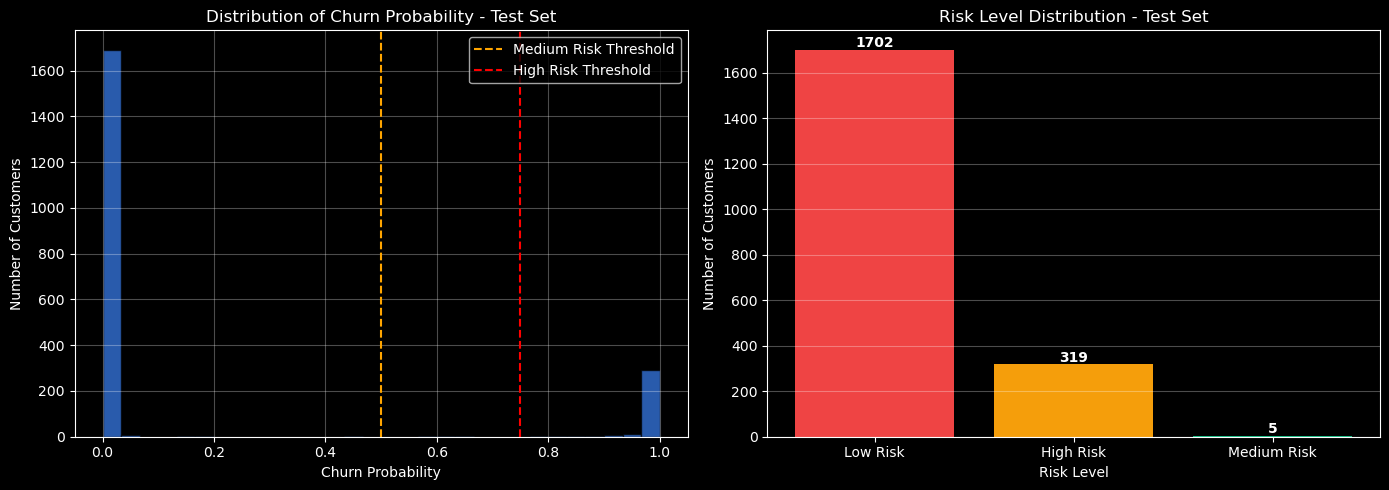

Test Predictions Visualization Complete


In [45]:
# Visualize test predictions distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of churn probabilities
axes[0].hist(test_results["churn_probability"], bins=30, color="#3B82F6", edgecolor="black", alpha=0.7)
axes[0].set_xlabel("Churn Probability")
axes[0].set_ylabel("Number of Customers")
axes[0].set_title("Distribution of Churn Probability - Test Set")
axes[0].axvline(0.5, color="orange", linestyle="--", label="Medium Risk Threshold")
axes[0].axvline(0.75, color="red", linestyle="--", label="High Risk Threshold")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Risk level distribution
risk_counts = test_results["risk_level"].value_counts()
axes[1].bar(risk_counts.index, risk_counts.values, color=["#EF4444", "#F59E0B", "#10B981"])
axes[1].set_xlabel("Risk Level")
axes[1].set_ylabel("Number of Customers")
axes[1].set_title("Risk Level Distribution - Test Set")
axes[1].grid(alpha=0.3, axis="y")

for i, v in enumerate(risk_counts.values):
    axes[1].text(i, v + 10, str(v), ha="center", fontweight="bold")

plt.tight_layout()
plt.show()

print("Test Predictions Visualization Complete")

In [47]:
# Save test results
# test_probs =round(test_probs, 2)

test_probs = test_probs.round(3)

test_results = test[[ID_COL]].copy()
test_results["churn_probability"] = test_probs
test_results["churn_prediction"] = test_preds

output_path = "../data/predictions/ChurnZero_Predictions.csv"
os.makedirs("../data/predictions", exist_ok=True)

test_results.to_csv(output_path, index=False)

print(f"Test results saved to: {output_path}")
print(f"Total predictions generated: {len(test_results)}")
print()
print("Columns in output:")
print(test_results.columns.tolist())
print()
print("Sample results:")
print(test_results.head(10))

Test results saved to: ../data/predictions/ChurnZero_Predictions.csv
Total predictions generated: 2026

Columns in output:
['customer_id', 'churn_probability', 'churn_prediction']

Sample results:
   customer_id  churn_probability  churn_prediction
0    767114958              0.000                 0
1    708123033              0.000                 0
2    715424283              0.001                 0
3    717865008              0.000                 0
4    710188308              0.000                 0
5    716574033              0.000                 0
6    713183508              0.000                 0
7    718583133              0.000                 0
8    783554958              0.000                 0
9    714418158              0.000                 0
